In [2]:
import os
import glob
import numpy as np
import matplotlib as mpl
import matplotlib.pyplot as plt
import matplotlib.cm as cm
import xarray as xr
import scipy.stats as st
from matplotlib.colors import BoundaryNorm
import matplotlib.gridspec as gridspec
import pandas as pd
import datetime
import copy
import seaborn as sns
import colorcet as cc
from sklearn.neighbors import KernelDensity
from scipy.ndimage import label, binary_dilation, generate_binary_structure, filters, iterate_structure
import warnings

In [3]:
def list_dirs(in_dir):
    """
    List sub-directories.
    """
    dirs = []
    for it in os.scandir(in_dir):
        if it.is_dir():
            dirs.append(it.path)
    return dirs

def find_lasso_files(start_dates, root_datadir, in_basename, domain):
    files = []
    # Loop over dates
    for ii in range(0, len(start_dates)):
        # Get sub-directories (cases)
        idate = start_dates[ii]
        case_dirs = list_dirs(f'{root_datadir}/{idate}/')
        if len(case_dirs) > 0:
            # Loop over cases
            for icase in case_dirs:
                # Find config sub-directories
                # config_dirs = list_dirs(icase)
                config_dirs = [f'{icase}/base/']
                if len(config_dirs) > 0:
                    # Loop over configs
                    for iconfig in config_dirs:
                        # Find track stats file
                        fname = sorted(glob.glob(f'{iconfig}/{domain}/stats/{in_basename}*nc'))
                        if len(fname) > 0:
                            files.append(fname[0])
    return files

In [4]:
# LASSO case dates
start_dates = [
    "20181129", 
    "20181204",
    "20181205", 
    "20181219", 
    "20190122", 
    # "20190123",
    "20190125",
    "20190129",
    "20190208",
]

# LASSO tracking directory
rootdir_les = '/gpfs/wolf/atm131/proj-shared/zfeng/cacti/les/'
rootdir_meso = '/gpfs/wolf/atm131/proj-shared/zfeng/cacti/meso/'
in_basename = 'trackstats_20'
in_basename_w = 'stats_3d_w_'
in_basename_env = 'stats_1d_env_'

figdir = '/gpfs/wolf/atm131/proj-shared/zfeng/cacti/les/figures/'

# Domain 4 boundaries
lon_range = [-65.4, -63.1]
lat_range = [-33.3, -30.8]
gridspacing_d3 = '500m'
gridspacing_d4 = '100m'

# Find LASSO files
files_d2 = find_lasso_files(start_dates, rootdir_meso, in_basename, 'd2')
files_d3 = find_lasso_files(start_dates, rootdir_les, in_basename, 'd3')
files_d4 = find_lasso_files(start_dates, rootdir_les, in_basename, 'd4')
wfiles_d2 = find_lasso_files(start_dates, rootdir_meso, in_basename_w, 'd2')
wfiles_d3 = find_lasso_files(start_dates, rootdir_les, in_basename_w, 'd3')
wfiles_d4 = find_lasso_files(start_dates, rootdir_les, in_basename_w, 'd4')
efiles_d2 = find_lasso_files(start_dates, rootdir_meso, in_basename_env, 'd2')
efiles_d3 = find_lasso_files(start_dates, rootdir_les, in_basename_env, 'd3')
efiles_d4 = find_lasso_files(start_dates, rootdir_les, in_basename_env, 'd4')

print(f'Number of stats files (D2): {len(files_d2)}')
print(f'Number of W files (D2): {len(wfiles_d2)}')
print(f'Number of ENV files (D2): {len(efiles_d2)}')

print(f'Number of stats files (D3): {len(files_d3)}')
print(f'Number of W files (D3): {len(wfiles_d3)}')
print(f'Number of ENV files (D3): {len(efiles_d3)}')

print(f'Number of stats files (D4): {len(files_d4)}')
print(f'Number of W files (D4): {len(wfiles_d4)}')
print(f'Number of ENV files (D4): {len(efiles_d4)}')

files_d2, files_d3, files_d4, wfiles_d2, wfiles_d3, wfiles_d4

Number of stats files (D2): 16
Number of W files (D2): 16
Number of ENV files (D2): 16
Number of stats files (D3): 16
Number of W files (D3): 16
Number of ENV files (D3): 16
Number of stats files (D4): 16
Number of W files (D4): 16
Number of ENV files (D4): 16


(['/gpfs/wolf/atm131/proj-shared/zfeng/cacti/meso//20181129/gefs03/base//d2/stats/trackstats_20181129.1200_20181130.0000.nc',
  '/gpfs/wolf/atm131/proj-shared/zfeng/cacti/meso//20181129/gefs18/base//d2/stats/trackstats_20181129.1200_20181130.0000.nc',
  '/gpfs/wolf/atm131/proj-shared/zfeng/cacti/meso//20181129/gefs00/base//d2/stats/trackstats_20181129.1200_20181130.0000.nc',
  '/gpfs/wolf/atm131/proj-shared/zfeng/cacti/meso//20181129/gefs09/base//d2/stats/trackstats_20181129.1200_20181130.0000.nc',
  '/gpfs/wolf/atm131/proj-shared/zfeng/cacti/meso//20181204/gefs19/base//d2/stats/trackstats_20181204.1200_20181205.0000.nc',
  '/gpfs/wolf/atm131/proj-shared/zfeng/cacti/meso//20181204/gefs18/base//d2/stats/trackstats_20181204.1200_20181205.0000.nc',
  '/gpfs/wolf/atm131/proj-shared/zfeng/cacti/meso//20181205/gefs01/base//d2/stats/trackstats_20181205.1200_20181206.0000.nc',
  '/gpfs/wolf/atm131/proj-shared/zfeng/cacti/meso//20181219/eda09/base//d2/stats/trackstats_20181219.1200_20181220.000

# Read and combine stats files

In [5]:
# # # Read ENV data (LASSO D2)
# dse_d2 = xr.open_mfdataset(efiles_d2, concat_dim='tracks', combine='nested')
# # # dse_d2['tracks'] = np.arange(0, ntracks_d2)
# dse_d2 = dse_d2.rename({'z': 'height'})
# dse_d2

In [6]:
# Read track data (LASSO D2)
dst_d2 = xr.open_mfdataset(files_d2, concat_dim='tracks', combine='nested', engine='netcdf4')
# Renumber tracks to make it continuous
ntracks_d2 = dst_d2.sizes['tracks']
dst_d2['tracks'] = np.arange(0, ntracks_d2)
print(f'Number of tracks (D2): {ntracks_d2}')

# Read W data (LASSO D2)
dsw_d2 = xr.open_mfdataset(wfiles_d2, concat_dim='tracks', combine='nested')
# Renumber tracks to make it continuous
dsw_d2['tracks'] = np.arange(0, ntracks_d2)

# Read ENV data (LASSO D2)
dse_d2 = xr.open_mfdataset(efiles_d2, concat_dim='tracks', combine='nested')
dse_d2['tracks'] = np.arange(0, ntracks_d2)
dse_d2 = dse_d2.rename({'z': 'height'})

# Combine 2D and 3D datasets by coordinates
ds_d2 = xr.combine_by_coords([dst_d2, dsw_d2, dse_d2], combine_attrs='drop_conflicts')
ntimes_d2 = ds_d2.sizes['times']
ds_d2

Number of tracks (D2): 5007


<xarray.Dataset>
Dimensions:                  (tracks: 5007, times: 212, z: 40, core: 20,
                              height: 101)
Coordinates:
  * tracks                   (tracks) int64 0 1 2 3 4 ... 5003 5004 5005 5006
  * times                    (times) int64 -12 -11 -10 -9 -8 ... 196 197 198 199
  * z                        (z) float64 250.0 500.0 750.0 ... 2e+04 2.1e+04
  * core                     (core) int64 0 1 2 3 4 5 6 ... 13 14 15 16 17 18 19
  * height                   (height) float64 0.0 200.0 400.0 ... 1.98e+04 2e+04
Data variables: (12/93)
    CoreArea_up              (tracks, times, z, core) float32 dask.array<chunksize=(219, 212, 40, 20), meta=np.ndarray>
    CoreMaxW_up              (tracks, times, z, core) float32 dask.array<chunksize=(219, 212, 40, 20), meta=np.ndarray>
    CoreMeanW_up             (tracks, times, z, core) float32 dask.array<chunksize=(219, 212, 40, 20), meta=np.ndarray>
    CoreMassFlux_up          (tracks, times, z, core) float32 dask.array<chunksize=(219, 212, 40, 20), meta=np.ndarray>
    CoreThteMax_up           (tracks, times, z, core) float32 dask.array<chunksize=(219, 212, 40, 20), meta=np.ndarray>
    CoreThteMean_up          (tracks, times, z, core) float32 dask.array<chunksize=(219, 212, 40, 20), meta=np.ndarray>
    ...                       ...
    start_split_tracknumber  (tracks) float64 dask.array<chunksize=(219,), meta=np.ndarray>
    start_split_timeindex    (tracks) float64 dask.array<chunksize=(219,), meta=np.ndarray>
    start_split_cloudnumber  (tracks) float64 dask.array<chunksize=(219,), meta=np.ndarray>
    end_merge_tracknumber    (tracks) float64 dask.array<chunksize=(219,), meta=np.ndarray>
    end_merge_timeindex      (tracks) float64 dask.array<chunksize=(219,), meta=np.ndarray>
    end_merge_cloudnumber    (tracks) float64 dask.array<chunksize=(219,), meta=np.ndarray>
Attributes:
    title:                 Tracked cell W statistics
    source_trackfile:      /gpfs/wolf/atm131/proj-shared/zfeng/cacti/meso/201...
    startdate:             20181129.1200
    enddate:               20181130.0000
    timegap_hour:          0.5
    time_resolution_hour:  0.08333
    pixel_radius_km:       2.5

In [7]:
# Read track data (LASSO D3)
dst_d3 = xr.open_mfdataset(files_d3, concat_dim='tracks', combine='nested', engine='netcdf4')
# Renumber tracks to make it continuous
ntracks_d3 = dst_d3.sizes['tracks']
dst_d3['tracks'] = np.arange(0, ntracks_d3)
print(f'Number of tracks (D3): {ntracks_d3}')

# Read W data (LASSO D3)
dsw_d3 = xr.open_mfdataset(wfiles_d3, concat_dim='tracks', combine='nested')
# Renumber tracks to make it continuous
dsw_d3['tracks'] = np.arange(0, ntracks_d3)

# Read ENV data (LASSO D3)
dse_d3 = xr.open_mfdataset(efiles_d3, concat_dim='tracks', combine='nested')
dse_d3['tracks'] = np.arange(0, ntracks_d3)
dse_d3 = dse_d3.rename({'z': 'height'})

# Combine 2D and 3D datasets by coordinates
ds_d3 = xr.combine_by_coords([dst_d3, dsw_d3, dse_d3], combine_attrs='drop_conflicts')
ntimes_d3 = ds_d3.sizes['times']
ds_d3

Number of tracks (D3): 8348


<xarray.Dataset>
Dimensions:                  (tracks: 8348, times: 212, z: 40, core: 10,
                              height: 101)
Coordinates:
  * tracks                   (tracks) int64 0 1 2 3 4 ... 8344 8345 8346 8347
  * times                    (times) int64 -12 -11 -10 -9 -8 ... 196 197 198 199
  * z                        (z) float64 250.0 500.0 750.0 ... 2e+04 2.1e+04
  * core                     (core) int64 0 1 2 3 4 5 6 7 8 9
  * height                   (height) float64 0.0 200.0 400.0 ... 1.98e+04 2e+04
Data variables: (12/93)
    CoreArea_up              (tracks, times, z, core) float32 dask.array<chunksize=(369, 212, 40, 10), meta=np.ndarray>
    CoreMaxW_up              (tracks, times, z, core) float32 dask.array<chunksize=(369, 212, 40, 10), meta=np.ndarray>
    CoreMeanW_up             (tracks, times, z, core) float32 dask.array<chunksize=(369, 212, 40, 10), meta=np.ndarray>
    CoreMassFlux_up          (tracks, times, z, core) float32 dask.array<chunksize=(369, 212, 40, 10), meta=np.ndarray>
    CoreThteMax_up           (tracks, times, z, core) float32 dask.array<chunksize=(369, 212, 40, 10), meta=np.ndarray>
    CoreThteMean_up          (tracks, times, z, core) float32 dask.array<chunksize=(369, 212, 40, 10), meta=np.ndarray>
    ...                       ...
    start_split_tracknumber  (tracks) float64 dask.array<chunksize=(369,), meta=np.ndarray>
    start_split_timeindex    (tracks) float64 dask.array<chunksize=(369,), meta=np.ndarray>
    start_split_cloudnumber  (tracks) float64 dask.array<chunksize=(369,), meta=np.ndarray>
    end_merge_tracknumber    (tracks) float64 dask.array<chunksize=(369,), meta=np.ndarray>
    end_merge_timeindex      (tracks) float64 dask.array<chunksize=(369,), meta=np.ndarray>
    end_merge_cloudnumber    (tracks) float64 dask.array<chunksize=(369,), meta=np.ndarray>
Attributes:
    title:                 Tracked cell W statistics
    source_trackfile:      /gpfs/wolf/atm131/proj-shared/zfeng/cacti/les/2018...
    startdate:             20181129.1200
    enddate:               20181130.0000
    timegap_hour:          0.5
    time_resolution_hour:  0.08333
    pixel_radius_km:       0.5

In [8]:
# Read track data (LASSO D4)
dst_d4 = xr.open_mfdataset(files_d4, concat_dim='tracks', combine='nested', engine='netcdf4')
# Renumber tracks to make it continuous
ntracks_d4 = dst_d4.sizes['tracks']
dst_d4['tracks'] = np.arange(0, ntracks_d4)
print(f'Number of tracks (D4): {ntracks_d4}')

# Read W data (LASSO D4)
dsw_d4 = xr.open_mfdataset(wfiles_d4, concat_dim='tracks', combine='nested')
# Renumber tracks to make it continuous
dsw_d4['tracks'] = np.arange(0, ntracks_d4)

# Read ENV data (LASSO D4)
dse_d4 = xr.open_mfdataset(efiles_d4, concat_dim='tracks', combine='nested')
dse_d4['tracks'] = np.arange(0, ntracks_d4)
dse_d4 = dse_d4.rename({'z': 'height'})

# Combine 2D and 3D datasets by coordinates
ds_d4 = xr.combine_by_coords([dst_d4, dsw_d4, dse_d4], combine_attrs='drop_conflicts')
ntimes_d4 = ds_d4.sizes['times']
ds_d4

Number of tracks (D4): 6463


<xarray.Dataset>
Dimensions:                  (tracks: 6463, times: 212, z: 40, core: 10,
                              height: 101)
Coordinates:
  * tracks                   (tracks) int64 0 1 2 3 4 ... 6459 6460 6461 6462
  * times                    (times) int64 -12 -11 -10 -9 -8 ... 196 197 198 199
  * z                        (z) float64 250.0 500.0 750.0 ... 2e+04 2.1e+04
  * core                     (core) int64 0 1 2 3 4 5 6 7 8 9
  * height                   (height) float64 0.0 200.0 400.0 ... 1.98e+04 2e+04
Data variables: (12/93)
    CoreArea_up              (tracks, times, z, core) float32 dask.array<chunksize=(295, 212, 40, 10), meta=np.ndarray>
    CoreMaxW_up              (tracks, times, z, core) float32 dask.array<chunksize=(295, 212, 40, 10), meta=np.ndarray>
    CoreMeanW_up             (tracks, times, z, core) float32 dask.array<chunksize=(295, 212, 40, 10), meta=np.ndarray>
    CoreMassFlux_up          (tracks, times, z, core) float32 dask.array<chunksize=(295, 212, 40, 10), meta=np.ndarray>
    CoreThteMax_up           (tracks, times, z, core) float32 dask.array<chunksize=(295, 212, 40, 10), meta=np.ndarray>
    CoreThteMean_up          (tracks, times, z, core) float32 dask.array<chunksize=(295, 212, 40, 10), meta=np.ndarray>
    ...                       ...
    start_split_tracknumber  (tracks) float64 dask.array<chunksize=(295,), meta=np.ndarray>
    start_split_timeindex    (tracks) float64 dask.array<chunksize=(295,), meta=np.ndarray>
    start_split_cloudnumber  (tracks) float64 dask.array<chunksize=(295,), meta=np.ndarray>
    end_merge_tracknumber    (tracks) float64 dask.array<chunksize=(295,), meta=np.ndarray>
    end_merge_timeindex      (tracks) float64 dask.array<chunksize=(295,), meta=np.ndarray>
    end_merge_cloudnumber    (tracks) float64 dask.array<chunksize=(295,), meta=np.ndarray>
Attributes:
    title:                 Tracked cell W statistics
    source_trackfile:      /gpfs/wolf/atm131/proj-shared/zfeng/cacti/les/2018...
    startdate:             20181129.1200
    enddate:               20181130.0000
    timegap_hour:          0.5
    time_resolution_hour:  0.08333
    pixel_radius_km:       0.5

## Subset tracks

In [9]:
# Get track min/max lat/lon
minlon_d2 = ds_d2['meanlon'].min(dim='times').load()
maxlon_d2 = ds_d2['meanlon'].max(dim='times').load()
minlat_d2 = ds_d2['meanlat'].min(dim='times').load()
maxlat_d2 = ds_d2['meanlat'].max(dim='times').load()
# Subset d2 tracks that are within D4 boundary
ds_d2 = ds_d2.where((minlon_d2 >= min(lon_range)) & (maxlon_d2 <= max(lon_range)) & \
                    (minlat_d2 >= min(lat_range)) & (maxlat_d2 <= max(lat_range)), drop=True)
# Renumber tracks to make it continuous
ntracks_d2 = ds_d2.sizes['tracks']
ds_d2['tracks'] = np.arange(0, ntracks_d2)
print(f'Number of tracks (D2): {ntracks_d2}')

Number of tracks (D2): 4031


In [10]:
# Get track min/max lat/lon
minlon_d3 = ds_d3['meanlon'].min(dim='times').load()
maxlon_d3 = ds_d3['meanlon'].max(dim='times').load()
minlat_d3 = ds_d3['meanlat'].min(dim='times').load()
maxlat_d3 = ds_d3['meanlat'].max(dim='times').load()
# Subset D3 tracks that are within D4 boundary
ds_d3 = ds_d3.where((minlon_d3 >= min(lon_range)) & (maxlon_d3 <= max(lon_range)) & \
                    (minlat_d3 >= min(lat_range)) & (maxlat_d3 <= max(lat_range)), drop=True)
# Renumber tracks to make it continuous
ntracks_d3 = ds_d3.sizes['tracks']
ds_d3['tracks'] = np.arange(0, ntracks_d3)
print(f'Number of tracks (D3): {ntracks_d3}')

Number of tracks (D3): 6783


In [11]:
# Get track min/max lat/lon
minlon_d4 = ds_d4['meanlon'].min(dim='times').load()
maxlon_d4 = ds_d4['meanlon'].max(dim='times').load()
minlat_d4 = ds_d4['meanlat'].min(dim='times').load()
maxlat_d4 = ds_d4['meanlat'].max(dim='times').load()
# Subset d4 tracks that are within D4 boundary
ds_d4 = ds_d4.where((minlon_d4 >= min(lon_range)) & (maxlon_d4 <= max(lon_range)) & \
                    (minlat_d4 >= min(lat_range)) & (maxlat_d4 <= max(lat_range)), drop=True)
# Renumber tracks to make it continuous
ntracks_d4 = ds_d4.sizes['tracks']
ds_d4['tracks'] = np.arange(0, ntracks_d4)
print(f'Number of tracks (D4): {ntracks_d4}')

Number of tracks (D4): 6311


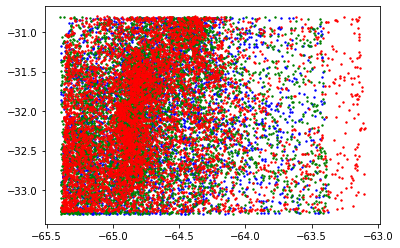

In [12]:
plt.scatter(ds_d2['meanlon'].mean(dim='times'), ds_d2['meanlat'].mean(dim='times'), s=2, c='b')
plt.scatter(ds_d3['meanlon'].mean(dim='times'), ds_d3['meanlat'].mean(dim='times'), s=2, c='g')
plt.scatter(ds_d4['meanlon'].mean(dim='times'), ds_d4['meanlat'].mean(dim='times'), s=2, c='r')

In [13]:
minlon_d4 = ds_d4['meanlon'].min().values
maxlon_d4 = ds_d4['meanlon'].max().values
minlat_d4 = ds_d4['meanlat'].min().values
maxlat_d4 = ds_d4['meanlat'].max().values
print(minlon_d4, maxlon_d4, minlat_d4, maxlat_d4)
print(lon_range, lat_range)

-65.39175 -63.10074 -33.27073 -30.800056
[-65.4, -63.1] [-33.3, -30.8]


## Find merge/split track indices

In [14]:
def find_merge_split_tracks(ds):
    """
    Find merge/split track indices.
    """
    # non-split tracks
    idx_nsplit = np.isnan(ds.start_split_cloudnumber.load())
    # non-merge tracks
    idx_nmerge = np.isnan(ds.end_merge_cloudnumber.load())
    # non-merge and non-split tracks
    idx_nms = np.isnan(ds.start_split_cloudnumber.load()) & np.isnan(ds.end_merge_cloudnumber.load())
    # merge or split tracks
    idx_ms = ~np.isnan(ds.start_split_cloudnumber.load()) | ~np.isnan(ds.end_merge_cloudnumber.load())
    # Group outputs to dictionary
    out_dict = {
        'ms': idx_ms,
        'nms': idx_nms,
        'nm': idx_nmerge,
        'ns': idx_nsplit,
    }
    return out_dict

In [15]:
tid_d2 = find_merge_split_tracks(ds_d2)
tid_d3 = find_merge_split_tracks(ds_d3)
tid_d4 = find_merge_split_tracks(ds_d4)

## Subset DataSets with non-merge/non-split tracks

In [16]:
dss_d2 = ds_d2.isel(tracks=tid_d2['nms'])
dss_d3 = ds_d3.isel(tracks=tid_d3['nms'])
dss_d4 = ds_d4.isel(tracks=tid_d4['nms'])

In [17]:
# Get some constents common for all Datasets
ntimes = dss_d2.dims['times']
nz = dss_d2.dims['z']
nheight = dss_d2.dims['height']
ncores = dss_d2.dims['core']

time_res = 5.0  # [min]
xtime = dss_d2.times * time_res
z = dss_d2.z / 1000.
height = dss_d2.height / 1000.

In [18]:
height

<xarray.DataArray 'height' (height: 101)>
array([ 0. ,  0.2,  0.4,  0.6,  0.8,  1. ,  1.2,  1.4,  1.6,  1.8,  2. ,
        2.2,  2.4,  2.6,  2.8,  3. ,  3.2,  3.4,  3.6,  3.8,  4. ,  4.2,
        4.4,  4.6,  4.8,  5. ,  5.2,  5.4,  5.6,  5.8,  6. ,  6.2,  6.4,
        6.6,  6.8,  7. ,  7.2,  7.4,  7.6,  7.8,  8. ,  8.2,  8.4,  8.6,
        8.8,  9. ,  9.2,  9.4,  9.6,  9.8, 10. , 10.2, 10.4, 10.6, 10.8,
       11. , 11.2, 11.4, 11.6, 11.8, 12. , 12.2, 12.4, 12.6, 12.8, 13. ,
       13.2, 13.4, 13.6, 13.8, 14. , 14.2, 14.4, 14.6, 14.8, 15. , 15.2,
       15.4, 15.6, 15.8, 16. , 16.2, 16.4, 16.6, 16.8, 17. , 17.2, 17.4,
       17.6, 17.8, 18. , 18.2, 18.4, 18.6, 18.8, 19. , 19.2, 19.4, 19.6,
       19.8, 20. ])
Coordinates:
  * height   (height) float64 0.0 200.0 400.0 600.0 ... 1.96e+04 1.98e+04 2e+04

In [19]:
# Get cell track lifetime: track_duration x time_resolution [min]
track_lifetime_d2 = dss_d2['track_duration'].load() * time_res
track_lifetime_d3 = dss_d3['track_duration'].load() * time_res
track_lifetime_d4 = dss_d4['track_duration'].load() * time_res

maxETH_10dbz_d2 = dss_d2['maxETH_10dbz'].load()
maxETH_10dbz_d3 = dss_d3['maxETH_10dbz'].load()
maxETH_10dbz_d4 = dss_d4['maxETH_10dbz'].load()

## Get lifetime-max 10dBZ ETH distributions & percentile values

In [20]:
eth_percentiles = [0.33, 0.5, 0.66]
trackmaxETH_10dbz_d2 = maxETH_10dbz_d2.max(dim='times')
max10dbz_pts_d2 = trackmaxETH_10dbz_d2.quantile(eth_percentiles, keep_attrs=True, skipna=True)
print(f"Max 10dBZ percentile values (D2): {max10dbz_pts_d2.values}")

Max 10dBZ percentile values (D2): [4.   4.75 6.  ]


In [21]:
trackmaxETH_10dbz_d3 = maxETH_10dbz_d3.max(dim='times')
max10dbz_pts_d3 = trackmaxETH_10dbz_d3.quantile(eth_percentiles, keep_attrs=True, skipna=True)
print(f"Max 10dBZ percentile values (D3): {max10dbz_pts_d3.values}")

Max 10dBZ percentile values (D3): [5.25 6.   7.  ]


In [22]:
trackmaxETH_10dbz_d4 = maxETH_10dbz_d4.max(dim='times')
max10dbz_pts_d4 = trackmaxETH_10dbz_d4.quantile(eth_percentiles, keep_attrs=True, skipna=True)
print(f"Max 10dBZ percentile values (D4): {max10dbz_pts_d4.values}")

Max 10dBZ percentile values (D4): [5.  5.5 6.5]


# Define shallow vs. deep cells
## Include duration threshold to both shallow/deep cells

In [23]:
# Define cell lifetime range for filtering, unit: [min]
track_lifetime_range = [15,100]

# Select percentiles to define shallow vs. deep cells
percentile_shallow = eth_percentiles[0]
percentile_deep = eth_percentiles[2]
print(f'Percentile thresholds for shallow: {percentile_shallow}, deep: {percentile_deep}')

Percentile thresholds for shallow: 0.33, deep: 0.66


(array([  0.,   0.,   0.,   0.,   0.,   0., 119., 129., 107.,  60.,  34.,
         32.,  21.,  11.,  15.]),
 array([ 0,  1,  2,  3,  4,  5,  6,  7,  8,  9, 10, 11, 12, 13, 14, 15]),
 <BarContainer object of 15 artists>)

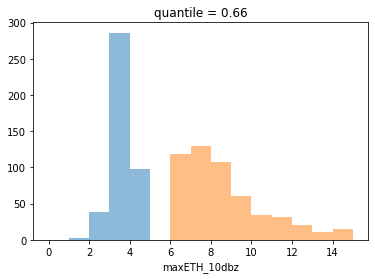

In [24]:
# Get shallow vs. deep cell/track IDs
cid_shallow_d2 = (trackmaxETH_10dbz_d2 <= max10dbz_pts_d2.sel(quantile=percentile_shallow)) & (track_lifetime_d2 >= min(track_lifetime_range))
cid_deep_d2 = (trackmaxETH_10dbz_d2 >= max10dbz_pts_d2.sel(quantile=percentile_deep)) & (track_lifetime_d2 >= min(track_lifetime_range))

# Check ETH histogram for shallow vs. deep groups
bins = np.arange(0,16,1)
trackmaxETH_10dbz_d2.sel(tracks=cid_shallow_d2).plot.hist(bins=bins, alpha=0.5, label='D2 shallow')
trackmaxETH_10dbz_d2.sel(tracks=cid_deep_d2).plot.hist(bins=bins, alpha=0.5, label='D2 deep')

(array([  0.,   0.,   0.,   0.,   0.,   0.,   0., 349., 273., 222., 104.,
         44.,  28.,  18.,  15.]),
 array([ 0,  1,  2,  3,  4,  5,  6,  7,  8,  9, 10, 11, 12, 13, 14, 15]),
 <BarContainer object of 15 artists>)

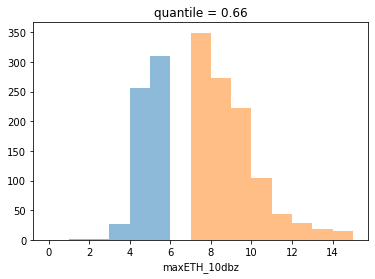

In [25]:
# Get shallow vs. deep cell/track IDs
cid_shallow_d3 = (trackmaxETH_10dbz_d3 <= max10dbz_pts_d3.sel(quantile=percentile_shallow)) & (track_lifetime_d3 >= min(track_lifetime_range))
cid_deep_d3 = (trackmaxETH_10dbz_d3 >= max10dbz_pts_d3.sel(quantile=percentile_deep)) & (track_lifetime_d3 >= min(track_lifetime_range))

# Check ETH histogram for shallow vs. deep groups
bins = np.arange(0,16,1)
trackmaxETH_10dbz_d3.sel(tracks=cid_shallow_d3).plot.hist(bins=bins, alpha=0.5, label='d3 shallow')
trackmaxETH_10dbz_d3.sel(tracks=cid_deep_d3).plot.hist(bins=bins, alpha=0.5, label='d3 deep')

(array([  0.,   0.,   0.,   0.,   0.,   0., 227., 341., 276., 154.,  82.,
         55.,  26.,  15.,  13.]),
 array([ 0,  1,  2,  3,  4,  5,  6,  7,  8,  9, 10, 11, 12, 13, 14, 15]),
 <BarContainer object of 15 artists>)

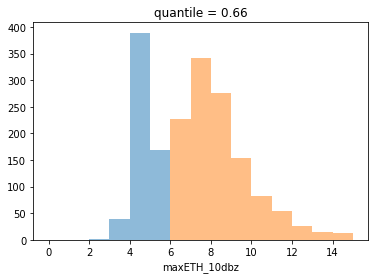

In [26]:
# Get shallow vs. deep cell/track IDs
cid_shallow_d4 = (trackmaxETH_10dbz_d4 <= max10dbz_pts_d4.sel(quantile=percentile_shallow)) & (track_lifetime_d4 >= min(track_lifetime_range))
cid_deep_d4 = (trackmaxETH_10dbz_d4 >= max10dbz_pts_d4.sel(quantile=percentile_deep)) & (track_lifetime_d4 >= min(track_lifetime_range))

# Check ETH histogram for shallow vs. deep groups
bins = np.arange(0,16,1)
trackmaxETH_10dbz_d4.sel(tracks=cid_shallow_d4).plot.hist(bins=bins, alpha=0.5, label='d4 shallow')
trackmaxETH_10dbz_d4.sel(tracks=cid_deep_d4).plot.hist(bins=bins, alpha=0.5, label='d4 deep')

## Subset DataSets by shallow vs deep cells

In [27]:
dss_shallow_d2 = dss_d2.sel(tracks=cid_shallow_d2)
dss_deep_d2 = dss_d2.sel(tracks=cid_deep_d2)

# Filter updrafts above 10dBZ ETH + 1 km
maxETH_10dbz_shallow_d2 = dss_shallow_d2['maxETH_10dbz'].load()
CoreArea_up_shallow_d2 = dss_shallow_d2['CoreArea_up'].where(height <= maxETH_10dbz_shallow_d2+1).isel(core=0).load()
CoreMaxW_up_shallow_d2 = dss_shallow_d2['CoreMaxW_up'].where(height <= maxETH_10dbz_shallow_d2+1).isel(core=0).load()

maxETH_10dbz_deep_d2 = dss_deep_d2['maxETH_10dbz'].load()
CoreArea_up_deep_d2 = dss_deep_d2['CoreArea_up'].where(height <= maxETH_10dbz_deep_d2+1).isel(core=0).load()
CoreMaxW_up_deep_d2 = dss_deep_d2['CoreMaxW_up'].where(height <= maxETH_10dbz_deep_d2+1).isel(core=0).load()

In [28]:
dss_shallow_d3 = dss_d3.sel(tracks=cid_shallow_d3)
dss_deep_d3 = dss_d3.sel(tracks=cid_deep_d3)

# Filter updrafts above 10dBZ ETH + 1 km
maxETH_10dbz_shallow_d3 = dss_shallow_d3['maxETH_10dbz'].load()
CoreArea_up_shallow_d3 = dss_shallow_d3['CoreArea_up'].where(height <= maxETH_10dbz_shallow_d3+1).isel(core=0).load()
CoreMaxW_up_shallow_d3 = dss_shallow_d3['CoreMaxW_up'].where(height <= maxETH_10dbz_shallow_d3+1).isel(core=0).load()

maxETH_10dbz_deep_d3 = dss_deep_d3['maxETH_10dbz'].load()
CoreArea_up_deep_d3 = dss_deep_d3['CoreArea_up'].where(height <= maxETH_10dbz_deep_d3+1).isel(core=0).load()
CoreMaxW_up_deep_d3 = dss_deep_d3['CoreMaxW_up'].where(height <= maxETH_10dbz_deep_d3+1).isel(core=0).load()

In [29]:
dss_shallow_d4 = dss_d4.sel(tracks=cid_shallow_d4)
dss_deep_d4 = dss_d4.sel(tracks=cid_deep_d4)

# Filter updrafts above 10dBZ ETH + 1 km
maxETH_10dbz_shallow_d4 = dss_shallow_d4['maxETH_10dbz'].load()
CoreArea_up_shallow_d4 = dss_shallow_d4['CoreArea_up'].where(height <= maxETH_10dbz_shallow_d4+1).isel(core=0).load()
CoreMaxW_up_shallow_d4 = dss_shallow_d4['CoreMaxW_up'].where(height <= maxETH_10dbz_shallow_d4+1).isel(core=0).load()

maxETH_10dbz_deep_d4 = dss_deep_d4['maxETH_10dbz'].load()
CoreArea_up_deep_d4 = dss_deep_d4['CoreArea_up'].where(height <= maxETH_10dbz_deep_d4+1).isel(core=0).load()
CoreMaxW_up_deep_d4 = dss_deep_d4['CoreMaxW_up'].where(height <= maxETH_10dbz_deep_d4+1).isel(core=0).load()

# TODO: This is where futher filtering of cells based on updraft properties can be added
## following the same method as in plot_shallow_deep_cell_w_stats.ipynb

In [39]:
xtime_preCI = xtime.sel(times=slice(-12,0))

## Composite shallow vs. deep DataSets to get mean

In [89]:
dss_shallow_avg_d2 = dss_shallow_d2.sel(times=slice(-12,0)).mean(dim='tracks').transpose()
dss_deep_avg_d2 = dss_deep_d2.sel(times=slice(-12,0)).mean(dim='tracks').transpose()

In [91]:
dss_shallow_avg_d3 = dss_shallow_d3.sel(times=slice(-12,0)).mean(dim='tracks').transpose()
dss_deep_avg_d3 = dss_deep_d3.sel(times=slice(-12,0)).mean(dim='tracks').transpose()

In [92]:
dss_shallow_avg_d4 = dss_shallow_d4.sel(times=slice(-12,0)).mean(dim='tracks').transpose()
dss_deep_avg_d4 = dss_deep_d4.sel(times=slice(-12,0)).mean(dim='tracks').transpose()

## Pull out any variables and calculate their differences

In [127]:
mucape_diff_avg_d2 = dss_deep_avg_d2['MUCAPE'] - dss_shallow_avg_d2['MUCAPE']
mucape_diff_avg_d3 = dss_deep_avg_d3['MUCAPE'] - dss_shallow_avg_d3['MUCAPE']
mucape_diff_avg_d4 = dss_deep_avg_d4['MUCAPE'] - dss_shallow_avg_d4['MUCAPE']

In [128]:
mucin_diff_avg_d2 = dss_deep_avg_d2['MUCIN'] - dss_shallow_avg_d2['MUCIN']
mucin_diff_avg_d3 = dss_deep_avg_d3['MUCIN'] - dss_shallow_avg_d3['MUCIN']
mucin_diff_avg_d4 = dss_deep_avg_d4['MUCIN'] - dss_shallow_avg_d4['MUCIN']

In [123]:
el_diff_avg_d2 = dss_deep_avg_d2['EL'] - dss_shallow_avg_d2['EL']
el_diff_avg_d3 = dss_deep_avg_d3['EL'] - dss_shallow_avg_d3['EL']
el_diff_avg_d4 = dss_deep_avg_d4['EL'] - dss_shallow_avg_d4['EL']

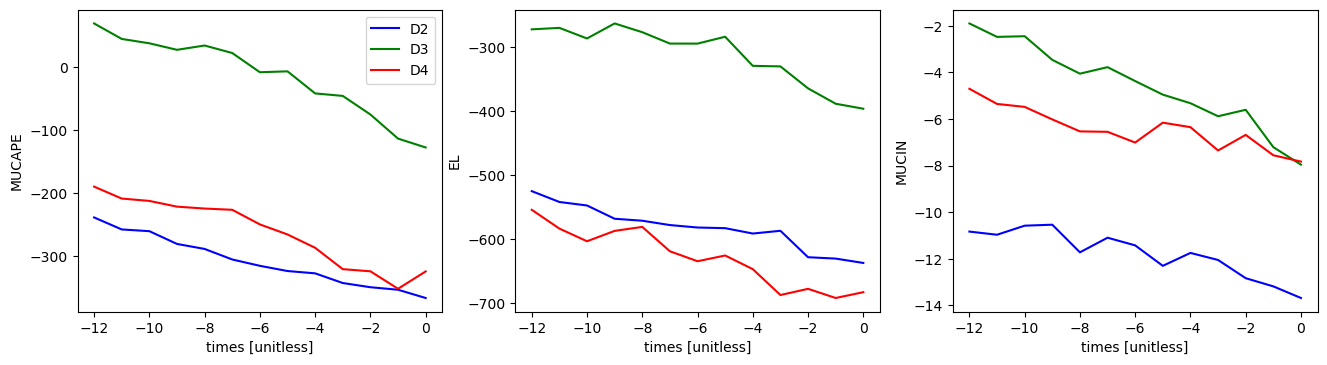

In [129]:
fig, axes = plt.subplots(1, 3, figsize=[16,4], dpi=100)
mucape_diff_avg_d2.plot(color='b', label='D2', ax=axes[0])
mucape_diff_avg_d3.plot(color='g', label='D3', ax=axes[0])
mucape_diff_avg_d4.plot(color='r', label='D4', ax=axes[0])
axes[0].legend()

el_diff_avg_d2.plot(color='b', label='D2', ax=axes[1])
el_diff_avg_d3.plot(color='g', label='D3', ax=axes[1])
el_diff_avg_d4.plot(color='r', label='D4', ax=axes[1])

mucin_diff_avg_d2.plot(color='b', label='D2', ax=axes[2])
mucin_diff_avg_d3.plot(color='g', label='D3', ax=axes[2])
mucin_diff_avg_d4.plot(color='r', label='D4', ax=axes[2])

In [109]:
rh600mb_diff_avg_d2 = dss_deep_avg_d2['rh_600mb'] - dss_shallow_avg_d2['rh_600mb']
rh600mb_diff_avg_d3 = dss_deep_avg_d3['rh_600mb'] - dss_shallow_avg_d3['rh_600mb']
rh600mb_diff_avg_d4 = dss_deep_avg_d4['rh_600mb'] - dss_shallow_avg_d4['rh_600mb']

In [112]:
rh500mb_diff_avg_d2 = dss_deep_avg_d2['rh_500mb'] - dss_shallow_avg_d2['rh_500mb']
rh500mb_diff_avg_d3 = dss_deep_avg_d3['rh_500mb'] - dss_shallow_avg_d3['rh_500mb']
rh500mb_diff_avg_d4 = dss_deep_avg_d4['rh_500mb'] - dss_shallow_avg_d4['rh_500mb']

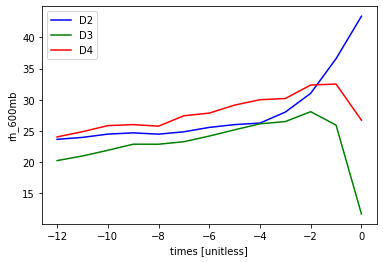

In [113]:
rh600mb_diff_avg_d2.plot(color='b', label='D2')
rh600mb_diff_avg_d3.plot(color='g', label='D3')
rh600mb_diff_avg_d4.plot(color='r', label='D4')
plt.legend()

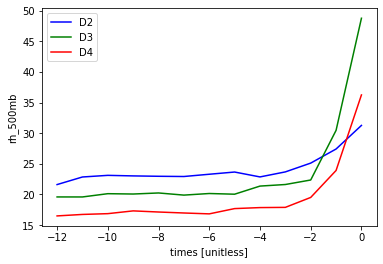

In [114]:
rh500mb_diff_avg_d2.plot(color='b', label='D2')
rh500mb_diff_avg_d3.plot(color='g', label='D3')
rh500mb_diff_avg_d4.plot(color='r', label='D4')
plt.legend()

In [96]:
rh_diff_avg_d2 = dss_deep_avg_d2['rh'] - dss_shallow_avg_d2['rh']
rh_diff_avg_d3 = dss_deep_avg_d3['rh'] - dss_shallow_avg_d3['rh']
rh_diff_avg_d4 = dss_deep_avg_d4['rh'] - dss_shallow_avg_d4['rh']

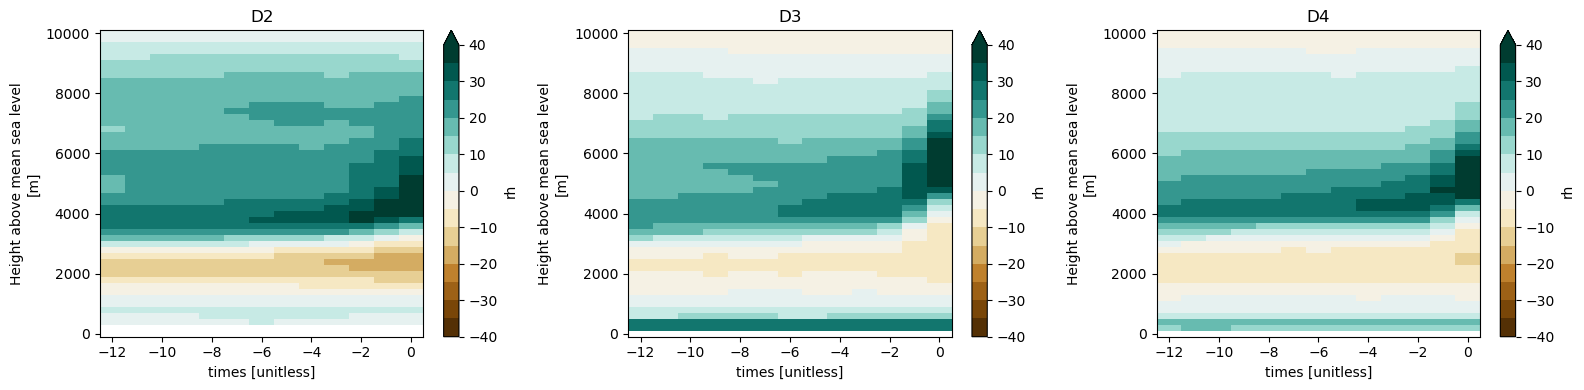

In [101]:
fig, axes = plt.subplots(1, 3, figsize=[16,4], dpi=100)
ax = axes[0]
levels = np.arange(-40, 41, 5)
cmap = plt.get_cmap('BrBG')
norm = mpl.colors.BoundaryNorm(levels, ncolors=cmap.N)
(rh_diff_avg_d2).sel(height=slice(0,10000)).plot(norm=norm, cmap=cmap, ax=ax)
ax.set_title('D2')
ax = axes[1]
(rh_diff_avg_d3).sel(height=slice(0,10000)).plot(norm=norm, cmap=cmap, ax=ax)
ax.set_title('D3')
ax = axes[2]
(rh_diff_avg_d4).sel(height=slice(0,10000)).plot(norm=norm, cmap=cmap, ax=ax)
ax.set_title('D4')

fig.tight_layout()

In [102]:
qv_diff_avg_d2 = (dss_deep_avg_d2['qv'] - dss_shallow_avg_d2['qv']) * 1000
qv_diff_avg_d3 = (dss_deep_avg_d3['qv'] - dss_shallow_avg_d3['qv']) * 1000
qv_diff_avg_d4 = (dss_deep_avg_d4['qv'] - dss_shallow_avg_d4['qv']) * 1000

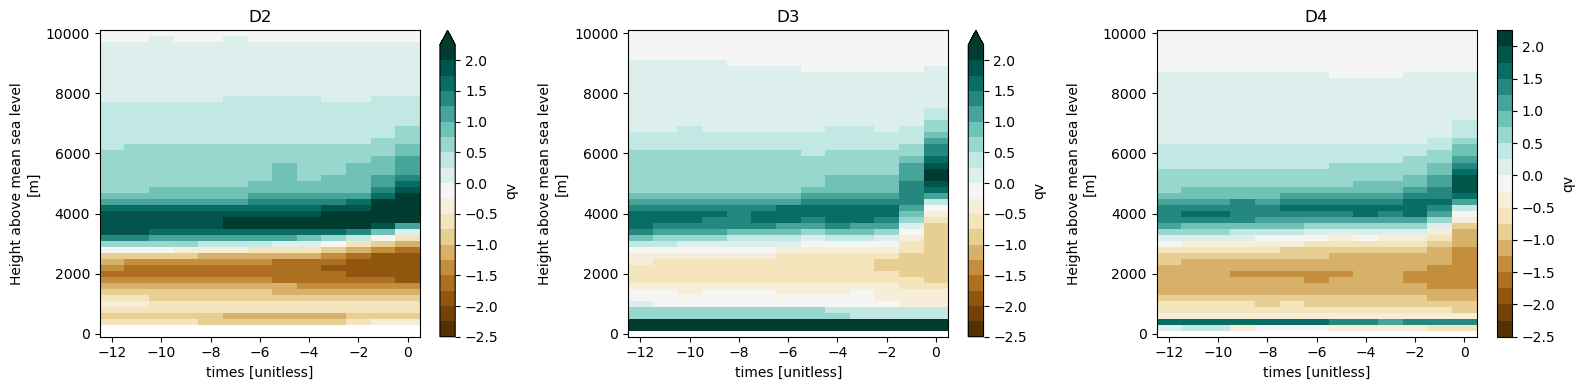

In [103]:
fig, axes = plt.subplots(1, 3, figsize=[16,4], dpi=100)
ax = axes[0]
levels = np.arange(-2.5, 2.5, 0.25)
cmap = plt.get_cmap('BrBG')
norm = mpl.colors.BoundaryNorm(levels, ncolors=cmap.N)
(qv_diff_avg_d2).sel(height=slice(0,10000)).plot(norm=norm, cmap=cmap, ax=ax)
ax.set_title('D2')
ax = axes[1]
(qv_diff_avg_d3).sel(height=slice(0,10000)).plot(norm=norm, cmap=cmap, ax=ax)
ax.set_title('D3')
ax = axes[2]
(qv_diff_avg_d4).sel(height=slice(0,10000)).plot(norm=norm, cmap=cmap, ax=ax)
ax.set_title('D4')

fig.tight_layout()

In [105]:
tk_diff_avg_d2 = dss_deep_avg_d2['temperature'] - dss_shallow_avg_d2['temperature']
tk_diff_avg_d3 = dss_deep_avg_d3['temperature'] - dss_shallow_avg_d3['temperature']
tk_diff_avg_d4 = dss_deep_avg_d4['temperature'] - dss_shallow_avg_d4['temperature']

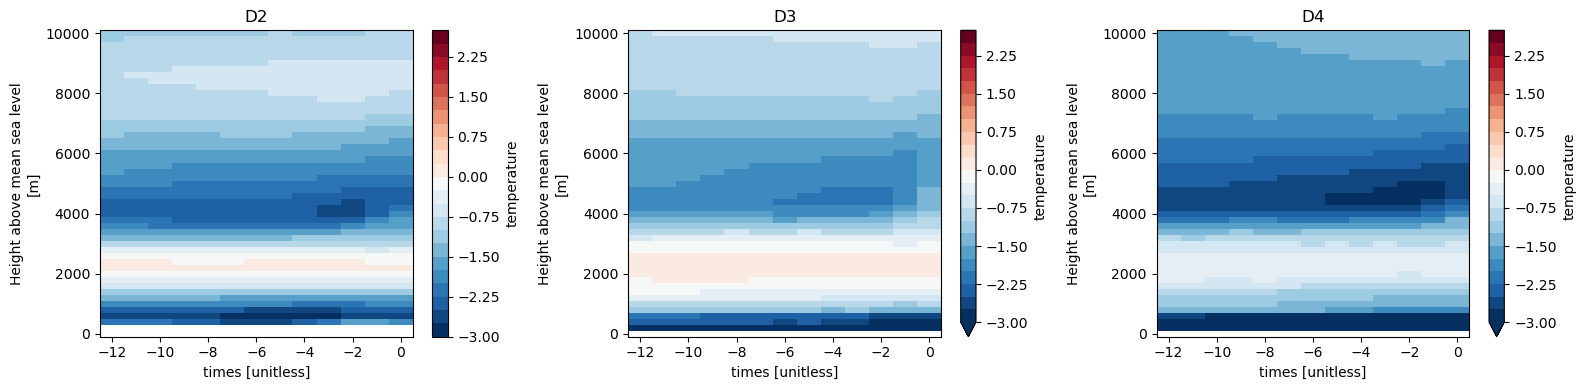

In [106]:
fig, axes = plt.subplots(1, 3, figsize=[16,4], dpi=100)
ax = axes[0]
levels = np.arange(-3., 3., 0.25)
cmap = plt.get_cmap('RdBu_r')
norm = mpl.colors.BoundaryNorm(levels, ncolors=cmap.N)
(tk_diff_avg_d2).sel(height=slice(0,10000)).plot(norm=norm, cmap=cmap, ax=ax)
ax.set_title('D2')
ax = axes[1]
(tk_diff_avg_d3).sel(height=slice(0,10000)).plot(norm=norm, cmap=cmap, ax=ax)
ax.set_title('D3')
ax = axes[2]
(tk_diff_avg_d4).sel(height=slice(0,10000)).plot(norm=norm, cmap=cmap, ax=ax)
ax.set_title('D4')

fig.tight_layout()

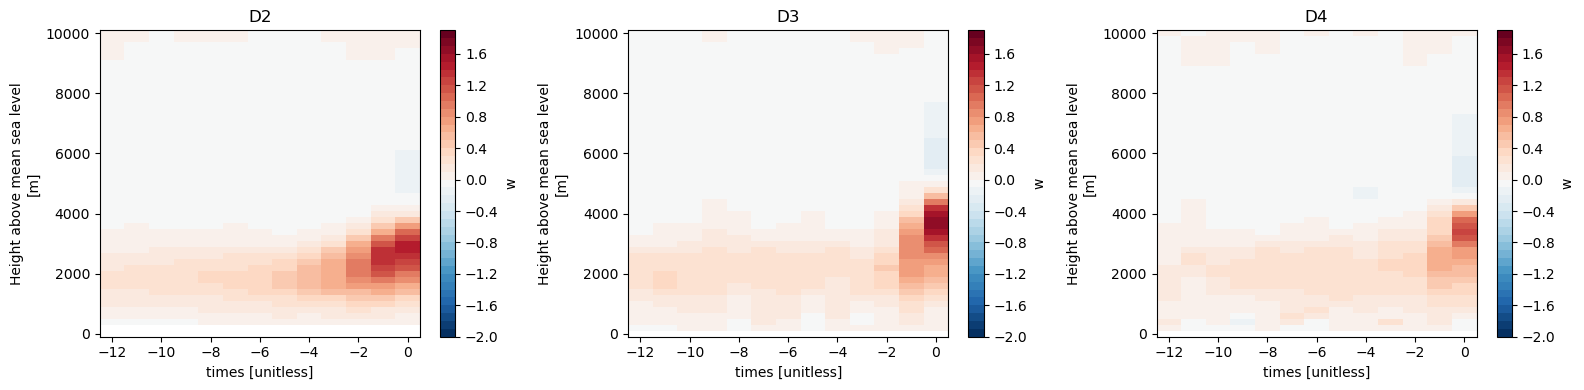

In [121]:
fig, axes = plt.subplots(1, 3, figsize=[16,4], dpi=100)
ax = axes[0]
levels = np.arange(-2., 2., 0.1)
cmap = plt.get_cmap('RdBu_r')
norm = mpl.colors.BoundaryNorm(levels, ncolors=cmap.N)
(dss_shallow_avg_d2.w).sel(height=slice(0,10000)).plot(norm=norm, cmap=cmap, ax=ax)
ax.set_title('D2')
ax = axes[1]
(dss_shallow_avg_d3.w).sel(height=slice(0,10000)).plot(norm=norm, cmap=cmap, ax=ax)
ax.set_title('D3')
ax = axes[2]
(dss_shallow_avg_d4.w).sel(height=slice(0,10000)).plot(norm=norm, cmap=cmap, ax=ax)
ax.set_title('D4')

fig.tight_layout()

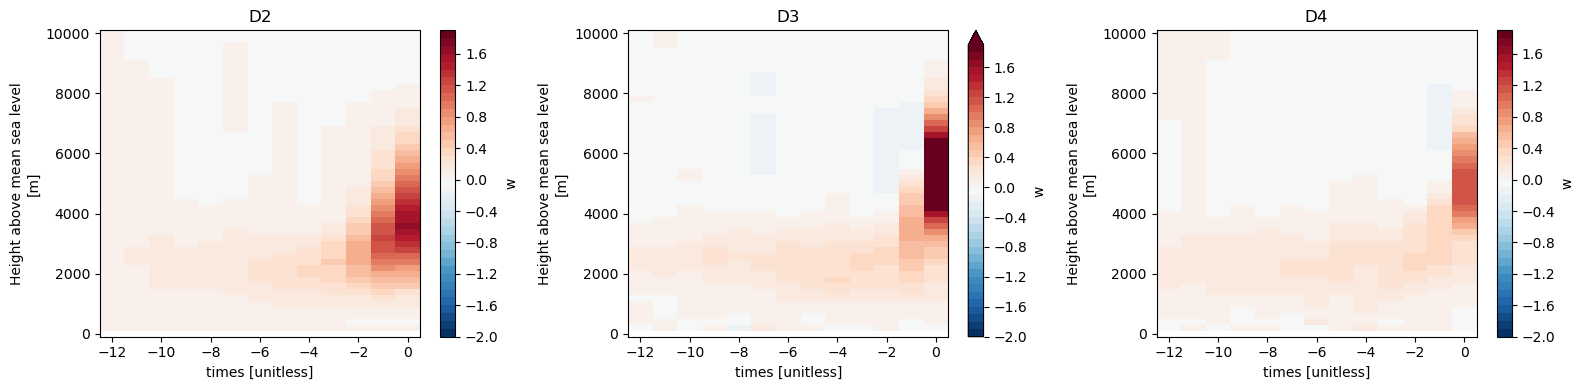

In [122]:
fig, axes = plt.subplots(1, 3, figsize=[16,4], dpi=100)
ax = axes[0]
levels = np.arange(-2., 2., 0.1)
cmap = plt.get_cmap('RdBu_r')
norm = mpl.colors.BoundaryNorm(levels, ncolors=cmap.N)
(dss_deep_avg_d2.w).sel(height=slice(0,10000)).plot(norm=norm, cmap=cmap, ax=ax)
ax.set_title('D2')
ax = axes[1]
(dss_deep_avg_d3.w).sel(height=slice(0,10000)).plot(norm=norm, cmap=cmap, ax=ax)
ax.set_title('D3')
ax = axes[2]
(dss_deep_avg_d4.w).sel(height=slice(0,10000)).plot(norm=norm, cmap=cmap, ax=ax)
ax.set_title('D4')

fig.tight_layout()